In [1]:
pip install ortools==9.7.2996

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

## Basic concepts of networkx

https://networkx.org/documentation/stable/index.html

In [3]:
G = nx.Graph()

edges = [(0, 1, 2.5),
         (1, 2, 1.2),
         (0, 3, 5.0),
         (3, 4, 0.8),
         (4, 2, 3.0),
         (1, 4, 2.0)]

G.add_weighted_edges_from(edges, weight='distance')

In [4]:
G.nodes

NodeView((0, 1, 2, 3, 4))

In [5]:
G.edges

EdgeView([(0, 1), (0, 3), (1, 2), (1, 4), (2, 4), (3, 4)])

In [6]:
G.edges(data=True)

EdgeDataView([(0, 1, {'distance': 2.5}), (0, 3, {'distance': 5.0}), (1, 2, {'distance': 1.2}), (1, 4, {'distance': 2.0}), (2, 4, {'distance': 3.0}), (3, 4, {'distance': 0.8})])

In [7]:
G.get_edge_data(0, 1)

{'distance': 2.5}

In [8]:
G.edges[0,1]['distance'] = 5

In [9]:
G.get_edge_data(0, 1)

{'distance': 5}

In [10]:
G.get_edge_data(1, 3)

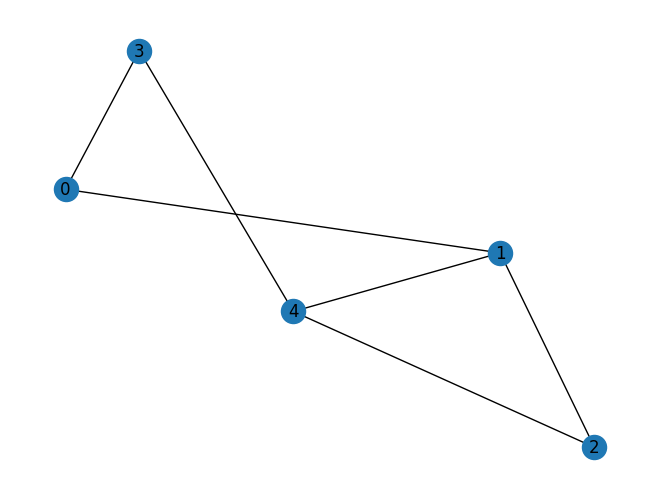

In [33]:
nx.draw(G, with_labels=True)

In [34]:
nx.kamada_kawai_layout(G, weight='distance')

{0: array([ 1.      , -0.055886]),
 1: array([-0.18501993,  0.23696714]),
 2: array([-0.3552586 ,  0.46739503]),
 3: array([-0.17992724, -0.40638322]),
 4: array([-0.27979423, -0.24209295])}

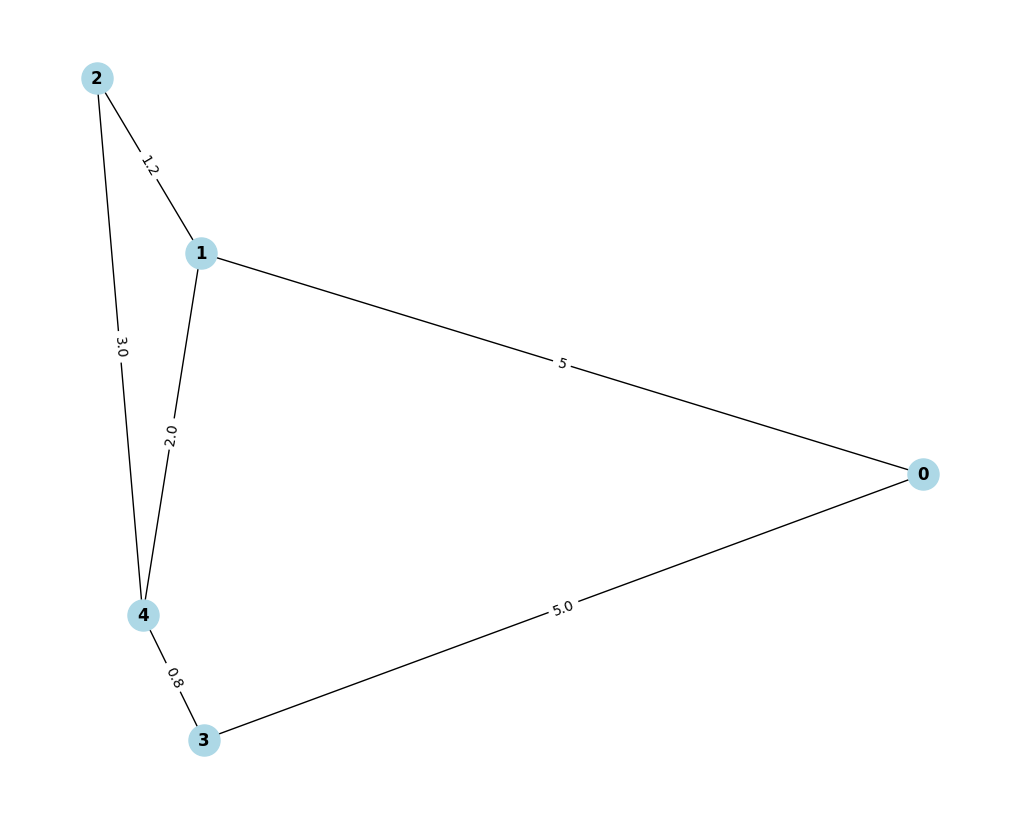

In [37]:
pos = nx.kamada_kawai_layout(G, weight='distance')

plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels={(u,v): f"{d['distance']}" for u,v,d in G.edges(data=True)})
plt.show()

In [38]:
G = nx.Graph()

edges = [
    (0, 1, {'distance': 2.5, 'slope': 1.5, 'traffic': 'low'}),
    (0, 3, {'distance': 5.0, 'slope': 3.0, 'traffic': 'high'}),
    (3, 4, {'distance': 0.8, 'slope': 0.5, 'traffic': 'low'}),
    (1, 4, {'distance': 0.8, 'slope': 0.5, 'traffic': 'low'}),
    (1, 2, {'distance': 1.2, 'slope': 0.8, 'traffic': 'medium'}),
    (5, 2, {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium'}),
    (1, 6, {'distance': 2.0, 'slope': 1.2, 'traffic': 'low'}),
    (5, 6, {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium'})
]

G.add_edges_from(edges)

for u, v, data in G.edges(data=True):
    print(f"{u}-{v}: {data}")

0-1: {'distance': 2.5, 'slope': 1.5, 'traffic': 'low'}
0-3: {'distance': 5.0, 'slope': 3.0, 'traffic': 'high'}
1-4: {'distance': 0.8, 'slope': 0.5, 'traffic': 'low'}
1-2: {'distance': 1.2, 'slope': 0.8, 'traffic': 'medium'}
1-6: {'distance': 2.0, 'slope': 1.2, 'traffic': 'low'}
3-4: {'distance': 0.8, 'slope': 0.5, 'traffic': 'low'}
2-5: {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium'}
5-6: {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium'}


In [39]:
time_dict = {(u, v): G[u][v]['distance'] * 1.2 for u, v in G.edges()}

In [40]:
time_dict

{(0, 1): 3.0,
 (0, 3): 6.0,
 (1, 4): 0.96,
 (1, 2): 1.44,
 (1, 6): 2.4,
 (3, 4): 0.96,
 (2, 5): 3.5999999999999996,
 (5, 6): 3.5999999999999996}

In [41]:
nx.set_edge_attributes(G, time_dict, name='time')

for u, v, data in G.edges(data=True):
    print(f"{u}-{v}: {data}")

0-1: {'distance': 2.5, 'slope': 1.5, 'traffic': 'low', 'time': 3.0}
0-3: {'distance': 5.0, 'slope': 3.0, 'traffic': 'high', 'time': 6.0}
1-4: {'distance': 0.8, 'slope': 0.5, 'traffic': 'low', 'time': 0.96}
1-2: {'distance': 1.2, 'slope': 0.8, 'traffic': 'medium', 'time': 1.44}
1-6: {'distance': 2.0, 'slope': 1.2, 'traffic': 'low', 'time': 2.4}
3-4: {'distance': 0.8, 'slope': 0.5, 'traffic': 'low', 'time': 0.96}
2-5: {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium', 'time': 3.5999999999999996}
5-6: {'distance': 3.0, 'slope': 1.8, 'traffic': 'medium', 'time': 3.5999999999999996}


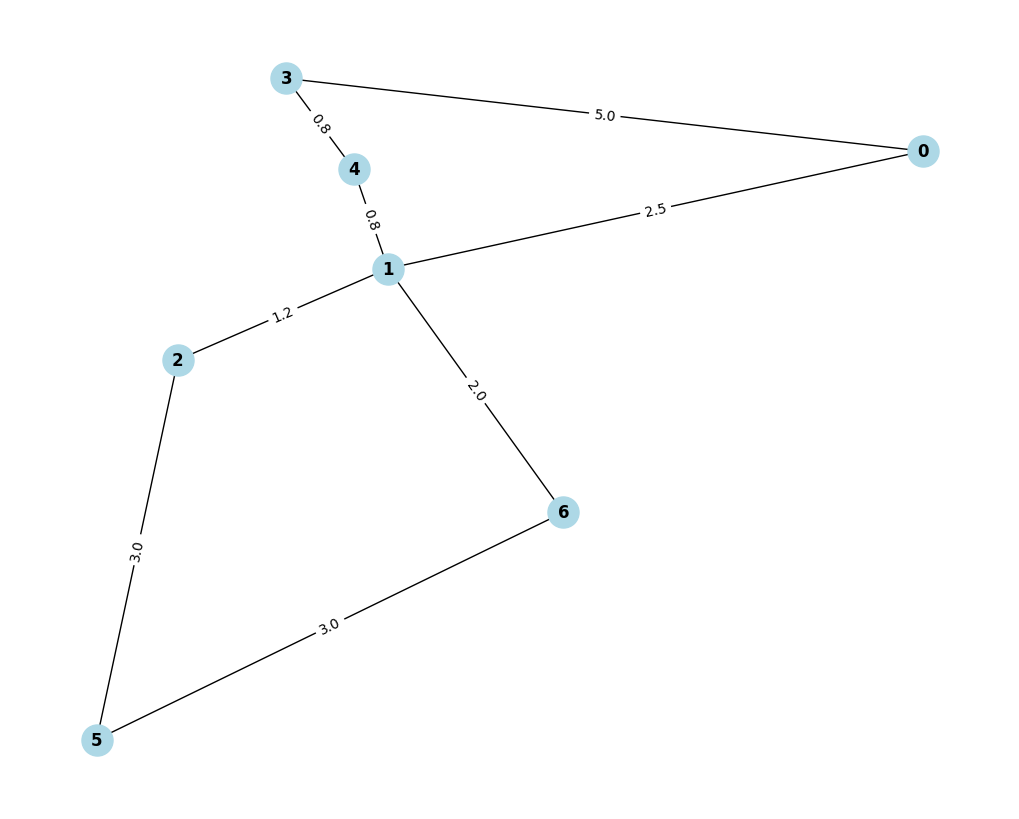

In [42]:
pos = nx.kamada_kawai_layout(G, weight='distance')

plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels={(u,v): f"{d['distance']}" for u,v,d in G.edges(data=True)})
plt.show()

In [43]:
betweenness = nx.betweenness_centrality(G, weight='distance')

In [44]:
betweenness

{0: 0.0,
 1: 0.8,
 3: 0.0,
 4: 0.3333333333333333,
 2: 0.26666666666666666,
 5: 0.0,
 6: 0.0}

In [45]:
from networkx.algorithms.community import louvain_communities

communities = list(louvain_communities(G, seed=42))
community_map = {node: i for i, comm in enumerate(communities) for node in comm}

In [46]:
communities

[{0, 1, 3, 4}, {2, 5, 6}]

/tmp/ipykernel_15854/54626425.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


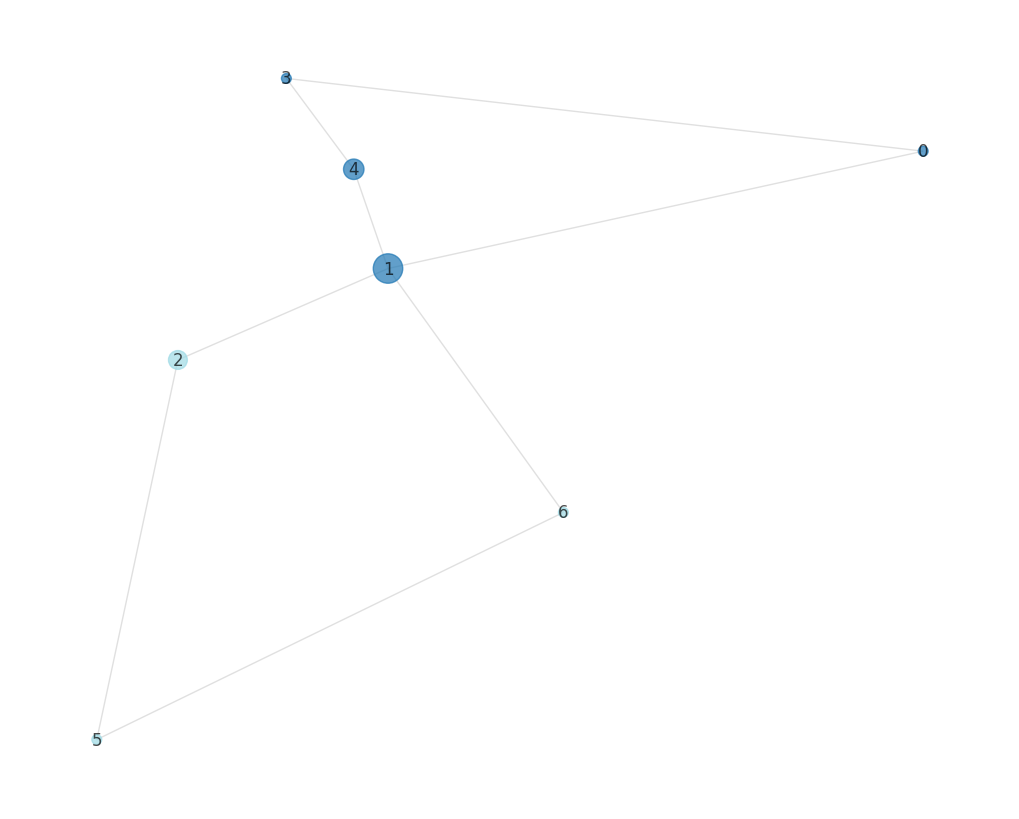

In [47]:
plt.figure(figsize=(10, 8))
pos = nx.kamada_kawai_layout(G, weight='distance')

node_colors = [community_map[n] for n in G.nodes()]
node_sizes = [500 * betweenness.get(n, 0) + 50 for n in G.nodes()]

nx.draw(G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        cmap='tab20',
        edge_color='lightgray',
        width=1,
        with_labels=True,
        alpha=0.7)

plt.axis('off')
plt.tight_layout()
plt.show()

## Load mobility graph from csv files

The urban mobility graph was created on Neo4j through the code in the GitHub repository: [https://github.com/federicarollo/GRAFMOVE](https://github.com/federicarollo/GRAFMOVE).

Then, the graph was exported as a collection of two CSV files, using the following Cypher queries:

- `MATCH (n) RETURN id(n) AS id, labels(n) AS labels, apoc.convert.toJson(properties(n)) AS properties` for nodes
- `MATCH (n)-[r]->(m) RETURN id(n) as source, id(m) as target, type(r) as type, apoc.convert.toJson(properties(r)) as properties` for edges

The graph structure follows the OpenStreetMap (OSM) structure:
- **Nodes** represent OSM-defined junctions or road shape points, mantaining the OSM identifier and the GPS coordinates as properties,
- **Edges** correspond to roads, with properties that describe their shape, length, type. The direction of the edge indicates the permitted travel direction.

<img src="https://raw.githubusercontent.com/federicarollo/ITADATA25/main/data/images/osm_structure_and_green.png" style="display: block; margin-left: auto; margin-right: auto;" alt="OSM structure" width="700"/>


<div>  
  <p><b>Graph structure:</b></p>
  <img src="https://raw.githubusercontent.com/federicarollo/ITADATA25/main/data/images/graph structure.png" width="500" alt="Graph structure">
</div>

In [48]:
nodes_filename = "https://raw.githubusercontent.com/federicarollo/ITADATA25/main/data/graphs/Modena/modena_nodes.csv"
edges_filename = "https://raw.githubusercontent.com/federicarollo/ITADATA25/main/data/graphs/Modena/modena_edges.csv"

In [49]:
nodes_df = pd.read_csv(nodes_filename)
edges_df = pd.read_csv(edges_filename)

In [50]:
import ast

def double_unescape_json(s):
    s = s.replace("\\n", "")
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        try:
            unescaped = s.encode('utf-8').decode('unicode_escape')
            return json.loads(unescaped)
        except json.JSONDecodeError:
            print(f"Warning: Could not parse properties string: {s}")
            return {}

In [51]:
edges_df['properties'][233]

'{\\"crash_risk\\":[0.2,1.1317460317460317,0.0,0.3713675213675213],\\"distance\\":139.06596543109077,\\"green_area\\":0,\\"green_area_weight\\":139.06596543109077,\\"length\\":\\"138.9104844602295\\",\\"maxspeed\\":\\"70\\",\\"crash_risk_density\\":[8.373572785294012E-6,4.7383788856465315E-5,0.0,1.5548364851325846E-5],\\"oneway\\":\\"True\\",\\"ref\\":\\"SS724\\",\\"crash_risk_per_meter\\":[0.0011644789834944196,0.00658947234310731,0.0,0.002162248368924467],\\"crash_risk_density_norm\\":[0.060809186016005864,0.1828168482443171,0.0,0.04031274398437343],\\"name\\":\\"Tangenziale Sud Gabriela Mistral\\",\\"lanes\\":\\"2\\",\\"geometry\\":\\"LINESTRING(10.8764911 44.6444336, 10.8759706 44.6456267)\\",\\"highway\\":\\"trunk\\",\\"reversed\\":\\"False\\"}'

In [52]:
double_unescape_json(edges_df['properties'][233])

{'crash_risk': [0.2, 1.1317460317460317, 0.0, 0.3713675213675213],
 'distance': 139.06596543109077,
 'green_area': 0,
 'green_area_weight': 139.06596543109077,
 'length': '138.9104844602295',
 'maxspeed': '70',
 'crash_risk_density': [8.373572785294012e-06,
  4.7383788856465315e-05,
  0.0,
  1.5548364851325846e-05],
 'oneway': 'True',
 'ref': 'SS724',
 'crash_risk_per_meter': [0.0011644789834944196,
  0.00658947234310731,
  0.0,
  0.002162248368924467],
 'crash_risk_density_norm': [0.060809186016005864,
  0.1828168482443171,
  0.0,
  0.04031274398437343],
 'name': 'Tangenziale Sud Gabriela Mistral',
 'lanes': '2',
 'geometry': 'LINESTRING(10.8764911 44.6444336, 10.8759706 44.6456267)',
 'highway': 'trunk',
 'reversed': 'False'}

In [53]:
double_unescape_json(edges_df['properties'][233])['distance']

139.06596543109077

In [54]:
%%time

G = nx.DiGraph()

nodes = [
    (
        row.id,
        {
            "labels": row.labels,
            **double_unescape_json(row.properties)
        }
    )
    for row in nodes_df.itertuples(index=False)
]

G.add_nodes_from(nodes)

edges = [
    (
        row.source,
        row.target,
        {
            "label": row.type,
            **double_unescape_json(row.properties)
        }
    )
    for row in edges_df.itertuples(index=False)
]

G.add_edges_from(edges)

CPU times: user 6.52 s, sys: 429 ms, total: 6.95 s
Wall time: 6.98 s


In [55]:
print(f"Nodes: {len(G.nodes())}, Edges: {len(G.edges())}")

Nodes: 60949, Edges: 166378


### What are the properties of the FootNode instances?

In [56]:
node_properties = set()

for _, data in G.nodes(data=True):
    if 'FootNode' in data.get('labels', []):
        node_properties.update(k for k in data.keys() if k != 'labels')

print(f"Properties of FootNode instances: {node_properties}")

Properties of FootNode instances: {'id', 'geometry', 'green_area', 'componentId', 'bbox', 'pedestrian_allowed_grafmove', 'cyclist_allowed_grafmove', 'latitude', 'ref', 'street_count', 'gtype', 'lon', 'x', 'railway', 'location', 'longitude', 'lat', 'y', 'highway'}


### What are the properties of the ROUTE edge instances?

In [57]:
edge_property = set()

for u, v, data in G.edges(data=True):
    if data.get('label') == 'ROUTE':
        edge_property.update(k for k in data.keys() if k != 'labels')

print(f"Properties of ROUTE instances: {edge_property}")

Properties of ROUTE instances: {'service', 'green_area', 'created_date', 'reversed', 'name', 'width', 'junction', 'crs', 'length', 'label', 'ref', 'tunnel', 'crash_risk_per_meter', 'crash_risk', 'distance', 'maxspeed', 'access', 'crash_risk_density', 'green_area_weight', 'foot_class', 'oneway', 'crash_risk_density_norm', 'bridge', 'bike_class', 'highway', 'created_with', 'geometry', 'lanes'}


### What are all the possible values of the *highway* property of ROUTE?

In [58]:
highway_values = set()

for _, _, data in G.edges(data=True):
    if data.get('label') == 'ROUTE' and 'highway' in data:
        highway_values.add(data['highway'])

print(highway_values)

{'service', 'primary_link', 'secondary_link', 'path', 'tertiary', 'secondary', 'steps', 'elevator', 'primary', 'trunk_link', 'motorway_link', 'trunk', 'busway', 'cycleway', 'footway', 'living_street', 'pedestrian', 'residential', 'tertiary_link', 'motorway', 'track', 'unclassified'}


### Road length values

In [59]:
route_distances = [
    data['distance']
    for u, v, data in G.edges(data=True)
    if data.get('label') == 'ROUTE' and 'distance' in data
]

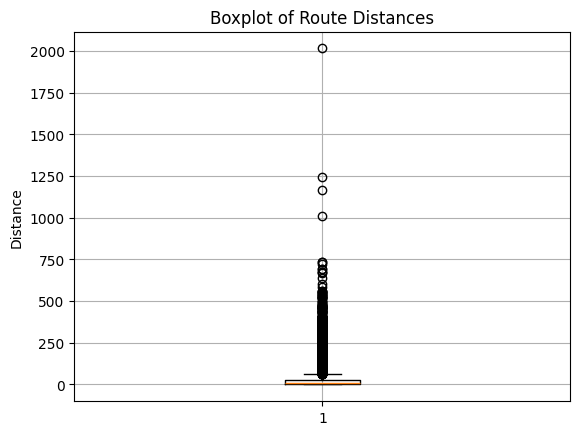

In [60]:
plt.boxplot(route_distances)
plt.title("Boxplot of Route Distances")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### Create a subgraph with FootNode e ROUTE

In [61]:
%%time

foot_nodes = [
    n for n, data in G.nodes(data=True)
    if "labels" in data and "FootNode" in data["labels"]
]

route_edges = [
    (u, v) for u, v, data in G.edges(data=True)
    if "label" in data and data["label"] == "ROUTE"
    and u in foot_nodes and v in foot_nodes
]

H = G.edge_subgraph(route_edges).copy()

CPU times: user 1min 12s, sys: 132 ms, total: 1min 12s
Wall time: 1min 13s


In [62]:
print(f"Nodes: {len(H.nodes())}, Edges: {len(H.edges())}")

Nodes: 40523, Edges: 86039


In [63]:
H.number_of_nodes()

40523

In [64]:
H.number_of_edges()

86039

In [65]:
nx.number_weakly_connected_components(H)

1

In [66]:
H.is_directed()

True

In [67]:
H_undirected = H.to_undirected()

In [68]:
def graph_statistics(G):
    print("Graph statistics:")
    print(f"  Number of nodes: {G.number_of_nodes()}")
    print(f"  Number of edges: {G.number_of_edges()}")

    degrees = [d for n, d in G.degree()]
    degree_counts = {}
    for d in degrees:
        degree_counts[d] = degree_counts.get(d, 0) + 1

    print(f"\nDegree distribution:")
    for d in sorted(degree_counts.keys())[:10]:
        print(f"  Degree {d}: {degree_counts[d]} nodes ({degree_counts[d]/G.number_of_nodes()*100:.1f}%)")

In [69]:
graph_statistics(H_undirected)

Graph statistics:
  Number of nodes: 40523
  Number of edges: 46849

Degree distribution:
  Degree 1: 2131 nodes (5.3%)
  Degree 2: 26729 nodes (66.0%)
  Degree 3: 8613 nodes (21.3%)
  Degree 4: 2988 nodes (7.4%)
  Degree 5: 54 nodes (0.1%)
  Degree 6: 8 nodes (0.0%)


In [70]:
# betweenness = nx.betweenness_centrality(H, weight='distance')

In [71]:
%%time

betweenness = nx.betweenness_centrality(H_undirected, k=500, weight="distance", normalized=True)

# degrees = dict(H_undirected.degree())
# top_k_nodes_degree = sorted(degrees, key=degrees.get, reverse=True)[:1000]

# betweenness = nx.betweenness_centrality_subset(H_undirected, top_k_nodes_degree, list(H_undirected.nodes()), weight="distance", normalized=True)

CPU times: user 3min 46s, sys: 243 ms, total: 3min 46s
Wall time: 3min 48s


In [72]:
type(betweenness)

dict

In [73]:
min(betweenness.values())

0.0

In [74]:
max(betweenness.values())

0.11468680437304114

In [75]:
threshold = np.percentile(list(betweenness.values()), 99)
top_k_nodes_betweenness = [n for n, b in betweenness.items() if b > threshold]
# top_k_nodes_betweenness = sorted(betweenness, key=betweenness.get, reverse=True)

In [76]:
len(top_k_nodes_betweenness)

406

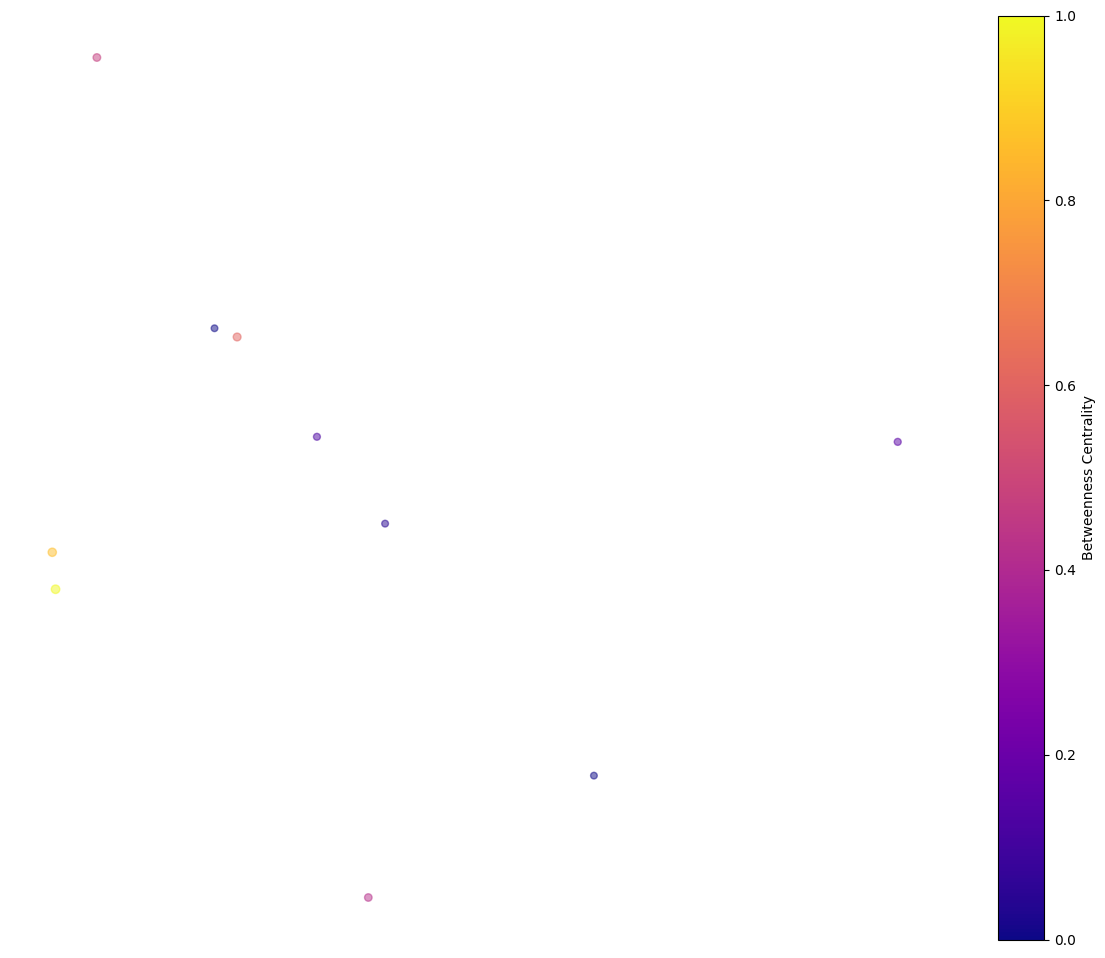

In [77]:
H_top = H_undirected.subgraph(top_k_nodes_betweenness[:10])

pos = {n: (H.nodes[n]['longitude'], H.nodes[n]['latitude']) for n in H_top.nodes()}

fig, ax = plt.subplots(figsize=(15, 12))
nx.draw(H_top, pos,
        node_size=[betweenness[n]*500 for n in H_top.nodes()],
        node_color=[betweenness[n] for n in H_top.nodes()],
        cmap='plasma',
        with_labels=False,
        alpha=0.5,
        edge_color='gray',
        width=0.8)

sm = plt.cm.ScalarMappable(cmap='plasma')

fig.colorbar(sm, ax=ax, label='Betweenness Centrality')
plt.axis('off')
plt.show()

In [78]:
pip install contextily

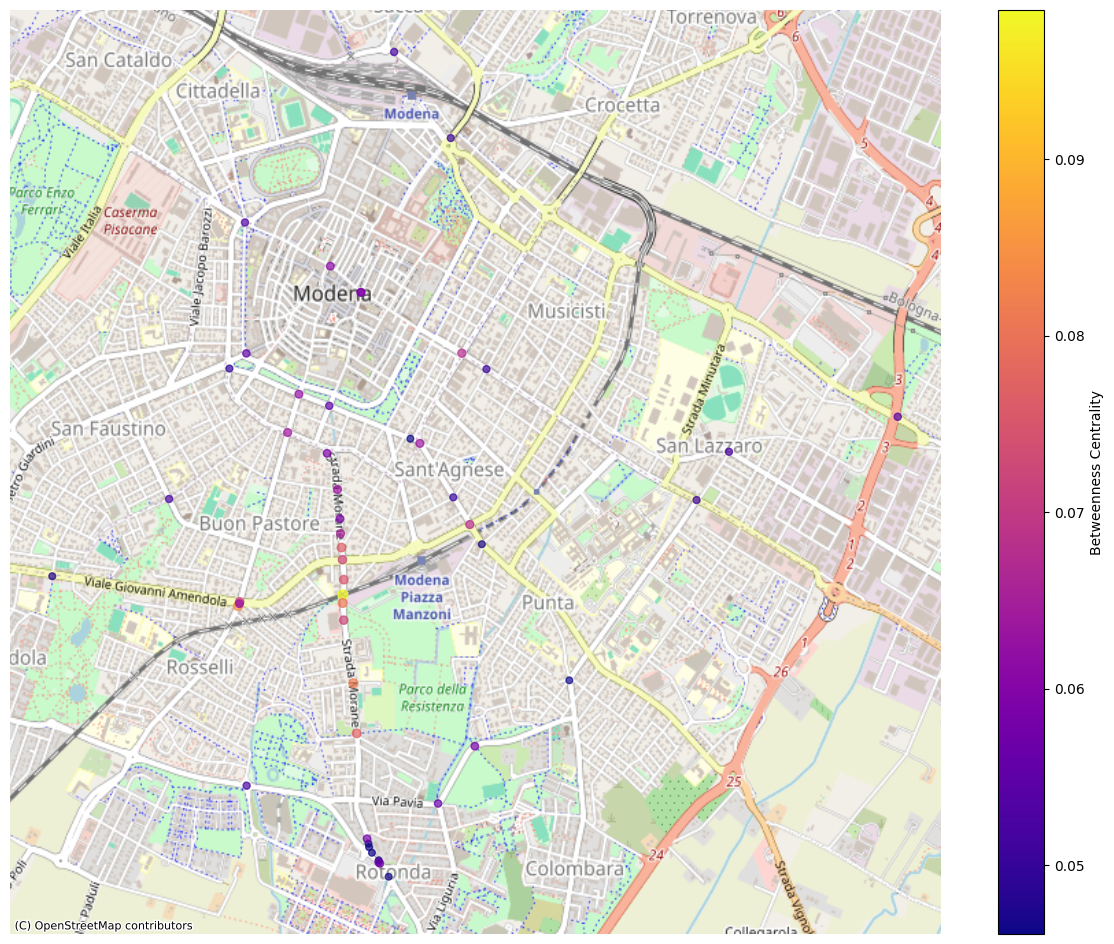

In [79]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

H_top = H_undirected.subgraph(top_k_nodes_betweenness[:50])

pos = {
    n: (H.nodes[n]['longitude'], H.nodes[n]['latitude'])
    for n in H_top.nodes()
}

gdf = gpd.GeoDataFrame(
    geometry=[
        Point(H.nodes[n]['longitude'], H.nodes[n]['latitude'])
        for n in H_top.nodes()
    ],
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

pos_3857 = {
    n: (geom.x, geom.y)
    for n, geom in zip(H_top.nodes(), gdf.geometry)
}

fig, ax = plt.subplots(figsize=(15, 12))

nx.draw(
    H_top,
    pos_3857,
    ax=ax,
    node_size=[betweenness[n] * 500 for n in H_top.nodes()],
    node_color=[betweenness[n] for n in H_top.nodes()],
    cmap='plasma',
    with_labels=False,
    alpha=0.7,
    edge_color='gray',
    width=0.8
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

sm = plt.cm.ScalarMappable(cmap='plasma')
sm.set_array([betweenness[n] for n in H_top.nodes()])

fig.colorbar(sm, ax=ax, label='Betweenness Centrality')

ax.set_axis_off()
plt.show()

In [80]:
def contract_intermediate_nodes_recursive(G):

    G_contracted = G.copy()

    total_contracted = 0
    iteration = 0

    while True:
        iteration += 1
        nodes_to_contract = [n for n in G_contracted.nodes() if G_contracted.degree(n) == 2]

        if not nodes_to_contract:
            break

        print(f"Iteration {iteration}: {len(nodes_to_contract)} nodes to contract...")

        contracted_in_iter = 0
        for node in nodes_to_contract:
            if node not in G_contracted.nodes():
                continue

            if G_contracted.degree(node) != 2:
                continue

            neighbors = list(G_contracted.neighbors(node))
            if len(neighbors) != 2:
                continue

            u, v = neighbors

            len1 = G_contracted[node][u].get('distance', 0)
            len2 = G_contracted[node][v].get('distance', 0)
            total_length = len1 + len2

            combined_attrs = {'distance': total_length}

            # for key, value in G_contracted[node][u].items():
            #     if key not in ['distance', 'length']:  # evita duplicati
            #         combined_attrs[key] = value

            G_contracted.add_edge(u, v, **combined_attrs)

            G_contracted.remove_node(node)
            contracted_in_iter += 1
            total_contracted += 1

        print(f"  Contracted nodes: {contracted_in_iter}")

    print(f"   Initial nodes: {G.number_of_nodes()}")
    print(f"   Final nodes: {G_contracted.number_of_nodes()}")
    print(f"   Contracted nodes: {total_contracted}")

    return G_contracted

H_only_junctions = contract_intermediate_nodes_recursive(H_undirected)

Iteration 1: 26729 nodes to contract...
  Contracted nodes: 26649
Iteration 2: 578 nodes to contract...
  Contracted nodes: 562
Iteration 3: 105 nodes to contract...
  Contracted nodes: 100
Iteration 4: 26 nodes to contract...
  Contracted nodes: 25
Iteration 5: 12 nodes to contract...
  Contracted nodes: 12
Iteration 6: 4 nodes to contract...
  Contracted nodes: 4
Iteration 7: 4 nodes to contract...
  Contracted nodes: 4
Iteration 8: 2 nodes to contract...
  Contracted nodes: 2
   Initial nodes: 40523
   Final nodes: 13165
   Contracted nodes: 27358


In [81]:
graph_statistics(H_only_junctions)

Graph statistics:
  Number of nodes: 13165
  Number of edges: 18988

Degree distribution:
  Degree 1: 2237 nodes (17.0%)
  Degree 3: 8035 nodes (61.0%)
  Degree 4: 2835 nodes (21.5%)
  Degree 5: 54 nodes (0.4%)
  Degree 6: 4 nodes (0.0%)


In [82]:
%%time

betweenness = nx.betweenness_centrality(H_only_junctions, k=500, weight="distance", normalized=True)

# degrees = dict(H_only_junctions.degree())
# top_k_nodes_degree = sorted(degrees, key=degrees.get, reverse=True)[:1000]

# betweenness = nx.betweenness_centrality_subset(H_only_junctions, top_k_nodes_degree, list(H_only_junctions.nodes()), weight="distance", normalized=True)

CPU times: user 1min 16s, sys: 68.4 ms, total: 1min 16s
Wall time: 1min 17s


In [83]:
min(betweenness.values())

0.0

In [84]:
max(betweenness.values())

0.1535437356518096

In [85]:
threshold = np.percentile(list(betweenness.values()), 99)
top_k_nodes_betweenness_only_junctions = [n for n, b in betweenness.items() if b > threshold]
# top_k_nodes_betweenness_only_junctions = sorted(betweenness, key=betweenness.get, reverse=True)

In [86]:
len(list(
    set(top_k_nodes_betweenness_only_junctions)
    & set(top_k_nodes_betweenness)
))

103

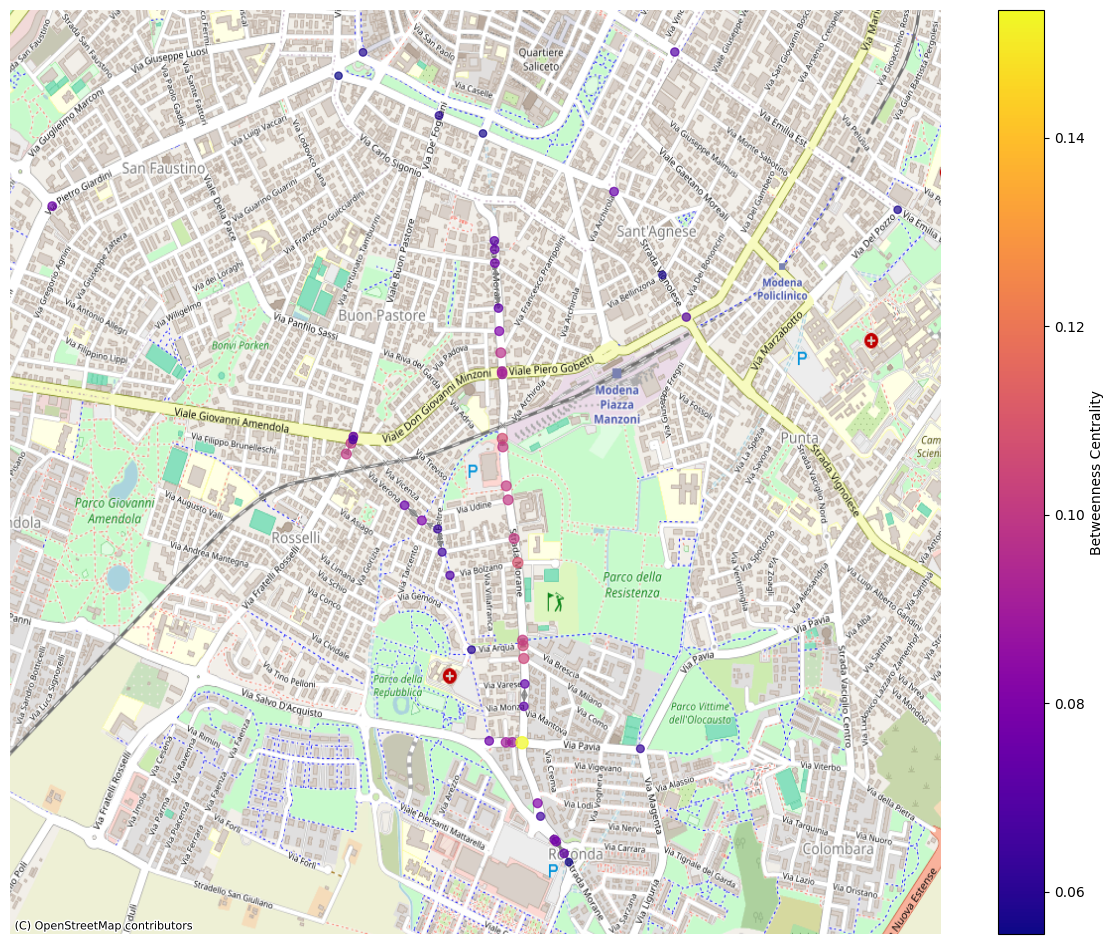

In [87]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

H_top = H.subgraph(top_k_nodes_betweenness_only_junctions[:50])

pos = {
    n: (H.nodes[n]['longitude'], H.nodes[n]['latitude'])
    for n in H_top.nodes()
}

gdf = gpd.GeoDataFrame(
    geometry=[
        Point(H.nodes[n]['longitude'], H.nodes[n]['latitude'])
        for n in H_top.nodes()
    ],
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

pos_3857 = {
    n: (geom.x, geom.y)
    for n, geom in zip(H_top.nodes(), gdf.geometry)
}

fig, ax = plt.subplots(figsize=(15, 12))

nx.draw(
    H_top,
    pos_3857,
    ax=ax,
    node_size=[betweenness[n] * 500 for n in H_top.nodes()],
    node_color=[betweenness[n] for n in H_top.nodes()],
    cmap='plasma',
    with_labels=False,
    alpha=0.7,
    edge_color='gray',
    width=0.8
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

sm = plt.cm.ScalarMappable(cmap='plasma')
sm.set_array([betweenness[n] for n in H_top.nodes()])

fig.colorbar(sm, ax=ax, label='Betweenness Centrality')

ax.set_axis_off()
plt.show()

### Now, find the communities!

https://networkx.org/documentation/stable/reference/algorithms/community.html

### Pathfinding

In [66]:
def get_shortest_path(G, source, target):
    paths = []

    for node, data in G.nodes(data=True):
        if 'FootNode' in data.get('labels', []) and str(data.get("id")) == source:
            source_node = node
            print("Source node found:", node)
            break
    else:
        print("Source node not found.")

    for node, data in G.nodes(data=True):
        if 'FootNode' in data.get('labels', []) and str(data.get("id")) == target:
            target_node = node
            print("Target node found:", node)
            break
    else:
        print("Target node not found.")

    return nx.shortest_path(G, source_node, target_node, weight="distance")

In [67]:
source, target = "250846426", "256411970"
# source, target ="10053840073", "2041913868"
# source, target ="250850846", "2021402066"

In [68]:
path = get_shortest_path(H_undirected, source, target)

Source node found: 409
Target node found: 983


In [69]:
len(path)

58

In [70]:
def get_path_length(G, path):
    length = 0

    for i in range(len(path)-1):
        u, v = path[i], path[i+1]

        length += G.edges[u, v]["distance"]

    return length

get_path_length(H_undirected, path)

847.9779739085399

### Pathfinding with POIs

In [71]:
def find_footnode(G, poi_name):
  foot_nodes = set()

  for node1, node2, data1 in G.edges(data=True):

      if data1.get('label') == 'TAGS':

          if ('Tag' in G.nodes[node2].get('labels', [])
              and G.nodes[node2].get('name')
              and G.nodes[node2].get('name').lower() == poi_name
          ):

              if ('POI' in G.nodes[node1].get('labels', [])):

                for a, b, data2 in G.edges(node1, data=True):

                    if (data2.get('label') == 'NEAR'
                        and 'FootNode' in G.nodes[b].get('labels')
                    ):
                      foot_nodes.add(G.nodes[b].get('id'))

  return foot_nodes.pop() if foot_nodes else None

In [72]:
source = find_footnode(G, "piazza roma")

In [73]:
target = find_footnode(G, "gelateria vignolese")

In [74]:
path = get_shortest_path(H_undirected, source, target)

Source node found: 35126
Target node found: 19169


In [75]:
get_path_length(H_undirected, path)

2898.0460765325856

In [76]:
import folium
from folium import PolyLine, Marker

lons = []
lats = []
for node in path:
    lat = H_undirected.nodes[node].get('lat')
    lon = H_undirected.nodes[node].get('lon')
    lats.append(lat)
    lons.append(lon)

center_lat = sum(lats) / len(lats)
center_lon = sum(lons) / len(lons)

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=14,
               tiles='OpenStreetMap',
               control_scale=True)

coordinates = list(zip(lats, lons))
PolyLine(
    coordinates,
    color='blue',
    weight=5,
    opacity=0.8,
    tooltip='Shortest Path'
).add_to(m)

for lat, lon in zip(lats[1:-1], lons[1:-1]):
    folium.CircleMarker(
        [lat, lon],
        radius=4,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7,
        popup=f'Node'
    ).add_to(m)

folium.Marker(
    [lats[0], lons[0]],
    popup='SOURCE',
    icon=folium.Icon(color='green', icon='play', prefix='fa')
).add_to(m)

folium.Marker(
    [lats[-1], lons[-1]],
    popup='TARGET',
    icon=folium.Icon(color='orange', icon='flag-checkered', prefix='fa')
).add_to(m)

m

### TO DO: define a function to generate the path that maximize the use of streets designed for pedestrians (property `foot_class` to minimize). Is the resulting path different from the shortest path?

## Traveling Salesperson Problem (TSP) using OR-Tools

https://developers.google.com/optimization/routing/tsp?hl=it

TSP implementation in networkx: https://networkx.org/documentation/stable/auto_examples/drawing/plot_tsp.html

In [3]:
# pip install --upgrade protobuf

In [4]:
# pip install --upgrade ortools

In [77]:
from ortools.constraint_solver import routing_enums_pb2, pywrapcp

def initialize_tsp(distance_matrix, depot_index=0):
    data = {}
    data['distance_matrix'] = distance_matrix
    data['num_vehicles'] = 1
    data['depot'] = depot_index
    return data

def print_solution(manager, routing, solution):

    print(f"Total cost: {solution.ObjectiveValue()}")

    index = routing.Start(0)
    plan_output = 'Optimal path:\n'
    route_distance = 0
    while not routing.IsEnd(index):
        plan_output += f'{manager.IndexToNode(index)}, '
        previous_index = index
        index = solution.Value(routing.NextVar(index))
        route_distance += routing.GetArcCostForVehicle(previous_index, index, 0)
    plan_output += f'{manager.IndexToNode(index)}'
    print(plan_output)

def solve_tsp(distance_matrix, depot=0):

    data = initialize_tsp(distance_matrix, depot)
    manager = pywrapcp.RoutingIndexManager(
        len(data['distance_matrix']), data['num_vehicles'], data['depot']
    )
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 5

    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_solution(manager, routing, solution)
        return solution.ObjectiveValue()
    else:
        print("No solution found")
        return None

In [78]:
distance_matrix = [
    [0, 245, 713, 1018, 1631],
    [245, 0, 1745, 1524, 831],
    [713, 1745, 0, 355, 920],
    [1018, 1524, 355, 0, 700],
    [1631, 831, 920, 700, 0]
]

solve_tsp(distance_matrix, depot=0)

Total cost: 2844
Optimal path:
0, 1, 4, 3, 2, 0


2844

In [79]:
from itertools import product

pois_name = ['piazza roma', 'gelateria vignolese', 'teatro storchi', 'palazzo dei musei', 'ghirlandina', 'collegio san carlo']

distance_matrix = np.zeros((len(pois_name), len(pois_name)))

for pois in list(product(pois_name, pois_name)):
    footnode1 = find_footnode(G, pois[0])
    footnode2 = find_footnode(G, pois[1])
    path = get_shortest_path(H_undirected, footnode1, footnode2)
    distance = get_path_length(H_undirected, path)
    print(distance)
    distance_matrix[pois_name.index(pois[0]), pois_name.index(pois[1])] = distance

Source node found: 35126
Target node found: 35126
0
Source node found: 35126
Target node found: 19169
2898.0460765325856
Source node found: 35126
Target node found: 34737
587.9199855851174
Source node found: 35126
Target node found: 4500
898.2102982732255
Source node found: 35126
Target node found: 26261
530.6676445465711
Source node found: 35126
Target node found: 31916
303.7380973342965
Source node found: 19169
Target node found: 35126
2898.0460765325824
Source node found: 19169
Target node found: 19169
0
Source node found: 19169
Target node found: 34737
2333.6473865943676
Source node found: 19169
Target node found: 4500
3239.053532033122
Source node found: 19169
Target node found: 26261
2871.3597211599017
Source node found: 19169
Target node found: 31916
2594.3079791982864
Source node found: 34737
Target node found: 35126
587.9199855851176
Source node found: 34737
Target node found: 19169
2333.6473865943685
Source node found: 34737
Target node found: 34737
0
Source node found: 34737

In [80]:
distance_matrix_int = np.array(distance_matrix).round().astype(int).tolist()

In [81]:
distance_matrix_int

[[0, 2898, 588, 898, 531, 304],
 [2898, 0, 2334, 3239, 2871, 2594],
 [588, 2334, 0, 1068, 651, 377],
 [898, 3239, 1068, 0, 523, 778],
 [531, 2871, 651, 523, 0, 342],
 [304, 2594, 377, 778, 342, 0]]

In [82]:
solution = solve_tsp(distance_matrix_int, depot=0)

Total cost: 7279
Optimal path:
0, 3, 4, 5, 1, 2, 0


In [83]:
index_to_visit = [...]

In [84]:
final_path = ""
for index in index_to_visit[:-1]:
    final_path += pois_name[index] + " -> "
final_path += pois_name[0]

print(final_path)

piazza roma -> palazzo dei musei -> ghirlandina -> collegio san carlo -> gelateria vignolese -> teatro storchi -> piazza roma
